### For each variable, generate a contributions plot based on the unit contributions

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import utils.behavioral_utils as behavioral_utils
import utils.information_utils as information_utils
import utils.visualization_utils as visualization_utils
import utils.glm_utils as glm_utils
from matplotlib import pyplot as plt
import utils.spike_utils as spike_utils
from constants.glm_constants import *
from constants.behavioral_constants import *

from constants.decoding_constants import *
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import *
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io

import seaborn as sns
plt.rcParams.update({'font.size': 16})

DECODE_VARS = ["pref", "conf", "choice", "reward"]


In [22]:
def plot_for_var_and_event(decode_var, trial_event, ax):
    args = argparse.Namespace(
        **BeliefPartitionConfigs()._asdict()
    )
    args.mode = decode_var
    args.subject = "both"

    if decode_var in ["choice", "reward"]:
        args.base_output_path = "/data/patrick_res/choice_reward"
    else: 
        args.beh_filters = {"Response": "Correct", "Choice": "Chose"}

    if decode_var == "reward":
        args.sig_unit_level = "response_99th_window_filter_drift"
    else: 
        args.sig_unit_level = f"{decode_var}_99th_window_filter_drift"

    all_conts = belief_partitions_io.get_contributions_for_all_time(args, region_level="structure_level2_cleaned")
    # group by time, region, sum contributions. 
    all_conts["TimeIdx"] = (all_conts["Time"] * 10).round().astype(int)
    all_conts["RegionAbbrev"] = all_conts["structure_level2_cleaned"].map(lambda x: visualization_utils.REGION_TO_ABBREV[x] if x in visualization_utils.REGION_TO_ABBREV else "other")
    all_conts = all_conts[all_conts["trial_event"] == trial_event]

    cont_sums = all_conts.groupby(["TimeIdx", "RegionAbbrev"])[f"mean_cont"].sum().reset_index()
    by_time = cont_sums.groupby("TimeIdx")["mean_cont"].sum().reset_index()

    cont_merged = pd.merge(by_time, cont_sums, on="TimeIdx", suffixes=("_total", "_region"))
    cont_merged["normed_cont"] = cont_merged["mean_cont_region"] / cont_merged["mean_cont_total"]

    args.trial_event = trial_event
    res = belief_partitions_io.read_results(args, FEATURES)

    res = res[res["mode"] == decode_var]
    res["TimeIdx"] = (res["Time"] * 10).round().astype(int)
    mean_acc = res.groupby(["TimeIdx"]).Accuracy.mean().reset_index()

    cont_merged = pd.merge(cont_merged, mean_acc, on="TimeIdx")
    # subtract out chance acc
    cont_merged["scaled_cont"] = cont_merged["normed_cont"] * (cont_merged["Accuracy"] - 0.5)
    cont_merged["Time"] = cont_merged["TimeIdx"] / 10

    # Plot
    colors = visualization_utils.REGION_TO_COLOR.copy()
    del colors["shuffle"]
    colors["other"] = "gray"
    # cont_merged = cont_merged.sort_values(by="RegionAbbrev", key=lambda x: x.map(order))
    per_regions = [cont_merged[cont_merged.RegionAbbrev == r].scaled_cont.values for r in colors.keys()]
    ax.stackplot(
        cont_merged["Time"].unique(),
        per_regions,
        labels=colors.keys(),
        baseline="sym",   # <- streamgraph magic
        alpha=0.9,
        colors=colors.values()
    )
    if decode_var == "pref" and trial_event == "StimOnset":
        ax.legend()

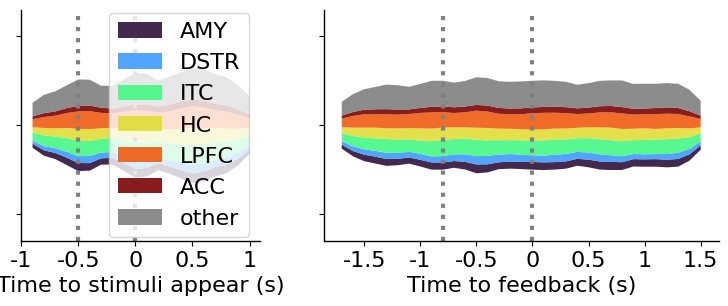

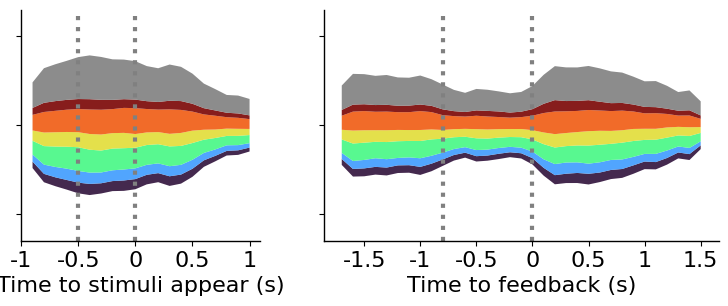

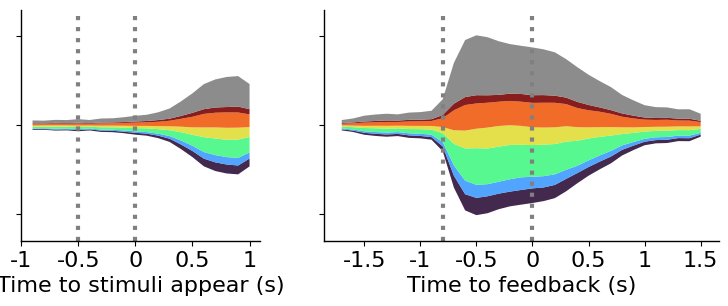

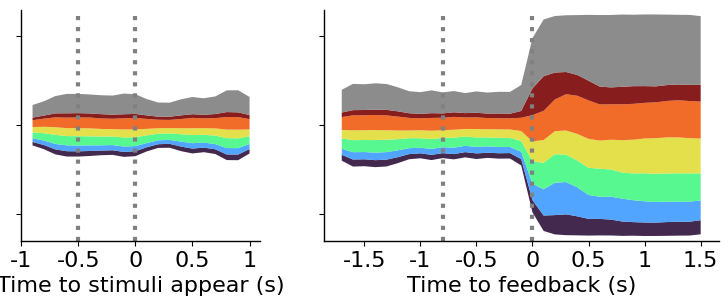

In [23]:
for decode_var in DECODE_VARS:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3), sharey='row', width_ratios=[20, 33])
    plot_for_var_and_event(decode_var, "StimOnset", ax1)
    plot_for_var_and_event(decode_var, "FeedbackOnsetLong", ax2)
    ax1.axvline(-.5, color='grey', linestyle='dotted', linewidth=3)
    ax1.axvline(0, color='grey', linestyle='dotted', linewidth=3)
    ax1.set_xlabel(f"Time to stimuli appear (s)")
    stim_ticks = [-1, -.5, 0, .5, 1]
    ax1.set_xticks(stim_ticks)
    ax1.set_xticklabels(stim_ticks)
    ax1.set_ylim([-0.26, 0.26])
    ax1.set_yticklabels([])
    ax1.set_ylabel("")
    ax2.axvline(-.8, color='grey', linestyle='dotted', linewidth=3)
    ax2.axvline(0, color='grey', linestyle='dotted', linewidth=3)
    ax2.set_xlabel(f"Time to feedback (s)")
    fb_ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
    ax2.set_xticks(fb_ticks)
    ax2.set_xticklabels(fb_ticks)
    visualization_utils.format_plot([ax1, ax2])
    fig.savefig(f"/data/patrick_res/figures/contribution_summaries/{decode_var}.svg")
    fig.savefig(f"/data/patrick_res/figures/contribution_summaries/{decode_var}.png", dpi=300)
